# Supermarket Sales Analysis

This project analyzes a supermarket sales dataset in order to understand
customer behavior, sales patterns, and key factors influencing revenue.

The analysis follows a full data science workflow including:

• Data exploration and visualization  
• Statistical inference  
• Regression modeling  
• Model validation  
• Time series analysis  

The goal of this analysis is to extract meaningful business insights
that could help improve sales strategies and better understand
customer purchasing behavior.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

## Load Dataset

In [2]:
sales = pd.read_csv("SuperMarketAnalysis.csv")

sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Dataset Overview

In [3]:
sales.shape

(1000, 17)

In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [5]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price,1000.0,55.672130,26.494628,10.080000,32.875000,55.230000,77.935000,99.960000
Quantity,1000.0,5.510000,2.923431,1.000000,3.000000,5.000000,8.000000,10.000000
Tax 5%,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Sales,1000.0,322.966749,245.885335,10.678500,124.422375,253.848000,471.350250,1042.650000
cogs,1000.0,307.587380,234.176510,10.170000,118.497500,241.760000,448.905000,993.000000
gross margin percentage,1000.0,4.761905,0.000000,4.761905,4.761905,4.761905,4.761905,4.761905
gross income,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Rating,1000.0,6.972700,1.718580,4.000000,5.500000,7.000000,8.500000,10.000000


The dataset contains transaction-level supermarket sales data.
Each row represents a single purchase made by a customer.

The dataset includes information about:

• Customer demographics (Gender, Customer type)
• Purchase characteristics (Product line, Quantity, Unit price)
• Payment method
• Sales performance metrics (Sales, Gross income, Rating)

These variables allow us to explore purchasing behavior,
Sales drivers, and build predictive models.

## Missing Values

In [6]:
sales.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

The dataset does not contain missing values,
therefore no data imputation or removal was required.

# Exploratory Data Analysis (EDA)

]In this section we explore the supermarket dataset using
descriptive statistics and visualizations.

The goal of EDA is to understand:

• distribution of key numerical variables  
• differences between customer groups  
• product category behavior  
• relationships between sales drivers

## Sales Distribution

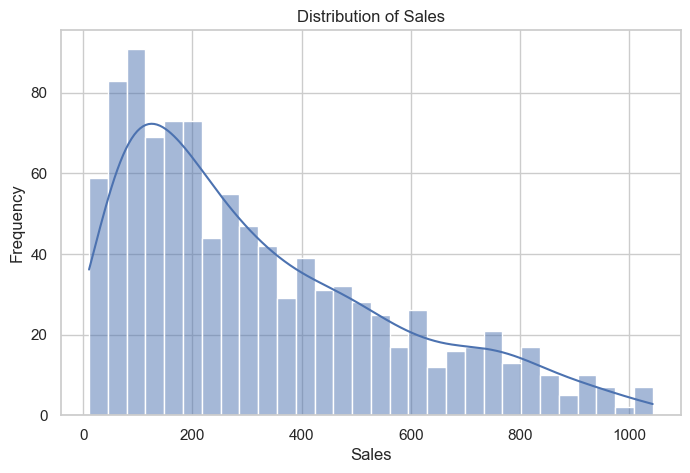

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

The distribution of sales shows that most transactions
are relatively small while larger purchases occur less frequently.

This pattern is typical for retail environments where
customers often purchase a limited number of items per visit.

## Quantity Distribution

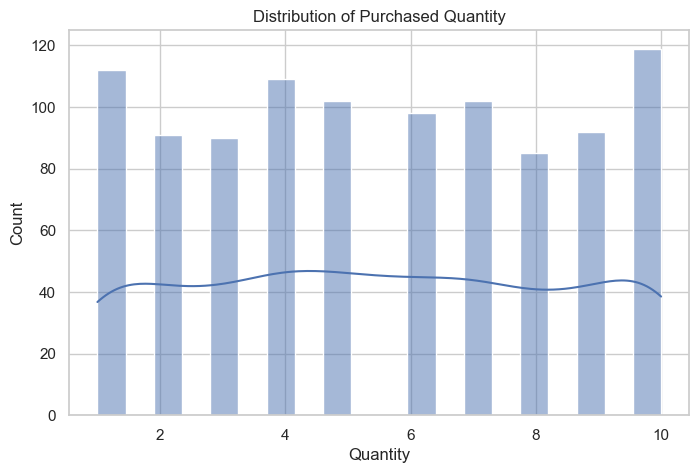

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Quantity"], bins=20, kde=True)

plt.title("Distribution of Purchased Quantity")

plt.show()

## Unit Price Distribution

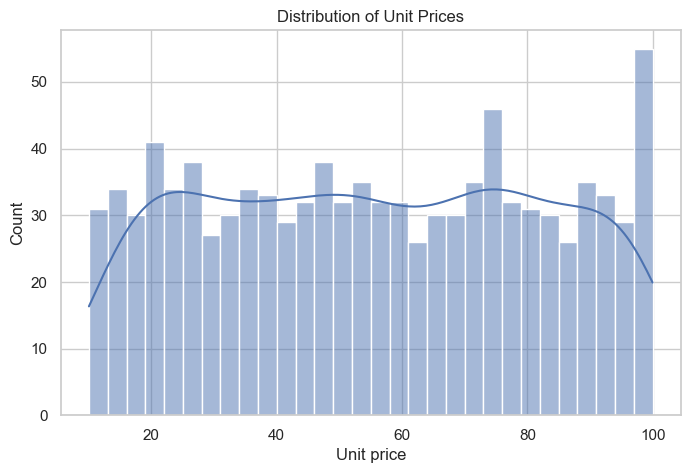

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Unit price"], bins=30, kde=True)

plt.title("Distribution of Unit Prices")

plt.show()

## Customer Ratings

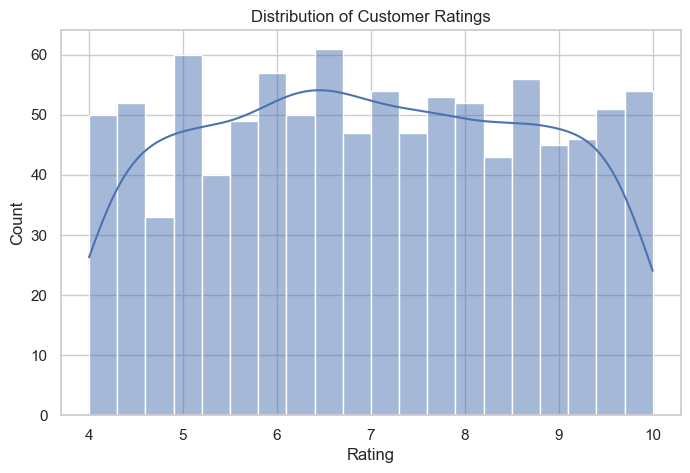

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Rating"], bins=20, kde=True)

plt.title("Distribution of Customer Ratings")

plt.show()

## Sales by Product Line

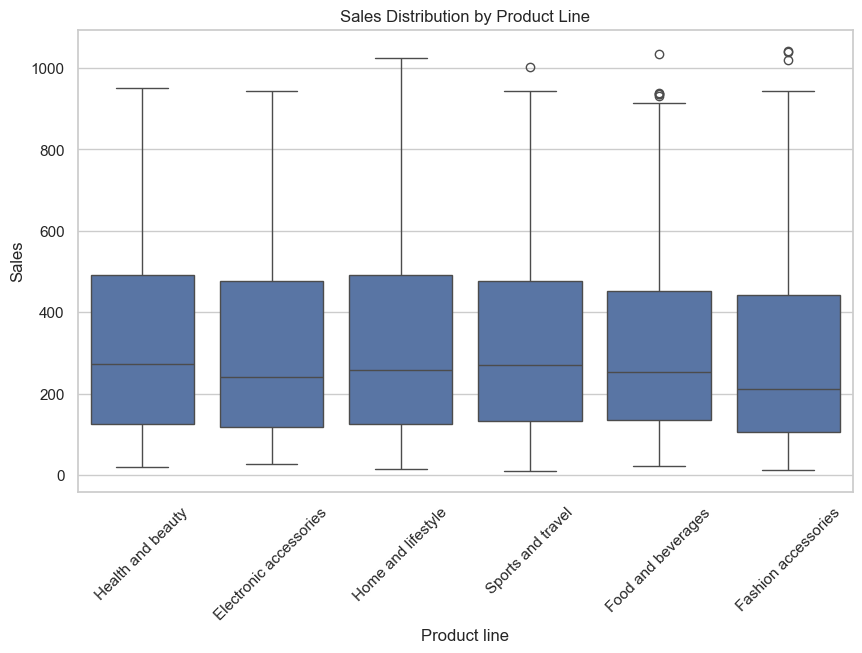

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Product line", y="Sales", data=sales)

plt.xticks(rotation=45)

plt.title("Sales Distribution by Product Line")

plt.show()

Different product categories show different sales distributions.

Some product lines generate larger transaction values,
indicating higher-priced items or larger purchase quantities.

## Sales by City

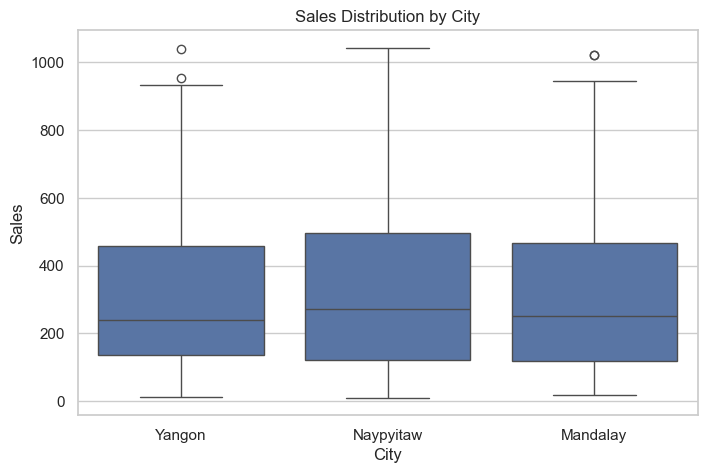

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x="City", y="Sales", data=sales)

plt.title("Sales Distribution by City")

plt.show()

## Payment Methods

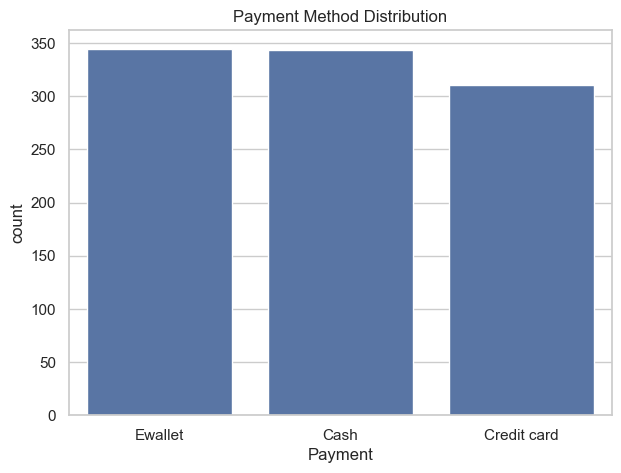

In [15]:
plt.figure(figsize=(7,5))

sns.countplot(x="Payment", data=sales)

plt.title("Payment Method Distribution")

plt.show()

## Customer Type

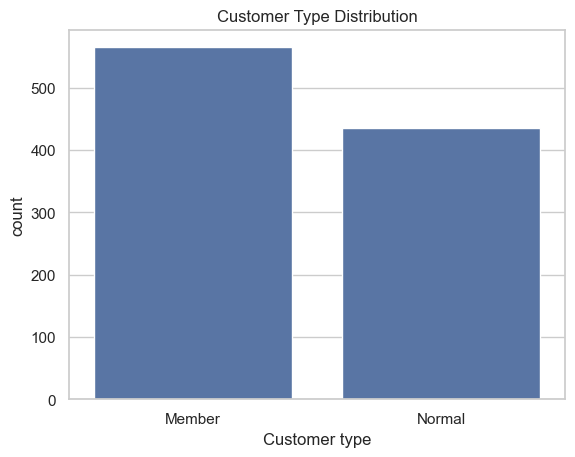

In [16]:
sns.countplot(x="Customer type", data=sales)

plt.title("Customer Type Distribution")

plt.show()

## Gender Distribution

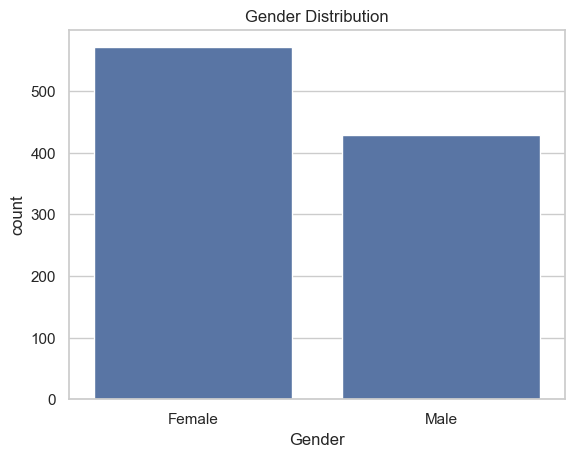

In [17]:
sns.countplot(x="Gender", data=sales)

plt.title("Gender Distribution")

plt.show()

## Correlation Matrix

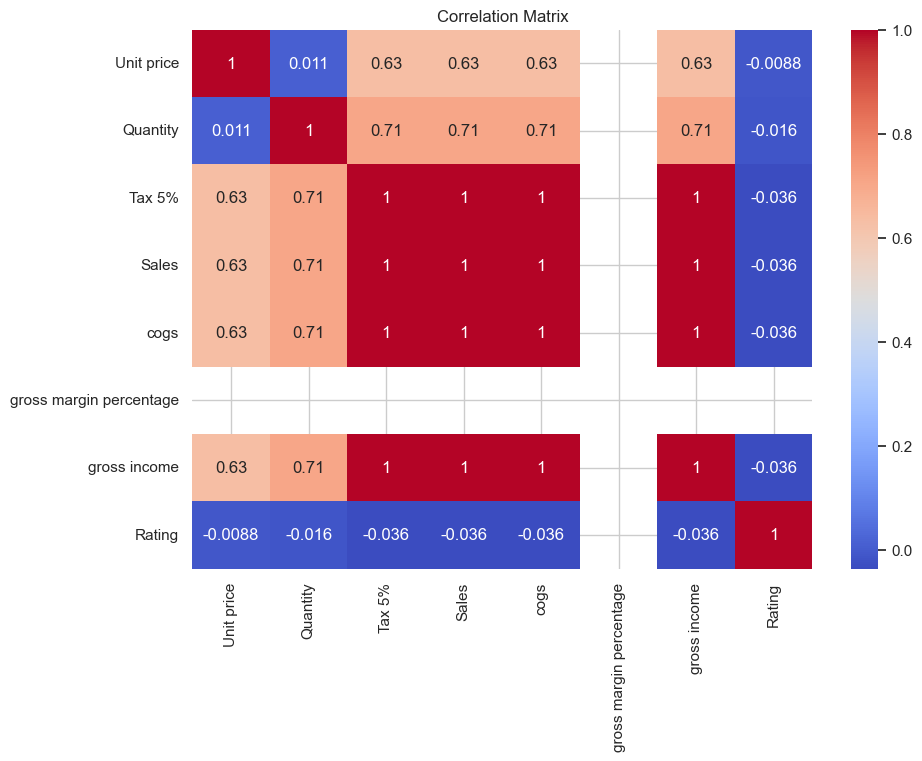

In [18]:
plt.figure(figsize=(10,7))

sns.heatmap(
    sales.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows relationships between numerical variables in the dataset.
Perfect correlations are observed between Sales, COGS, Tax 5%, and Gross Income because these variables are mathematically derived from one another.
Additionally, the variable "gross margin percentage" has no variation in the dataset, resulting in undefined correlations (NaN values), which appear as blank spaces in the heatmap.
Sales also shows a strong positive correlation with Quantity and a moderate correlation with Unit Price, which is expected since total transaction value depends on both the number of items purchased and their price.

## Pairplot

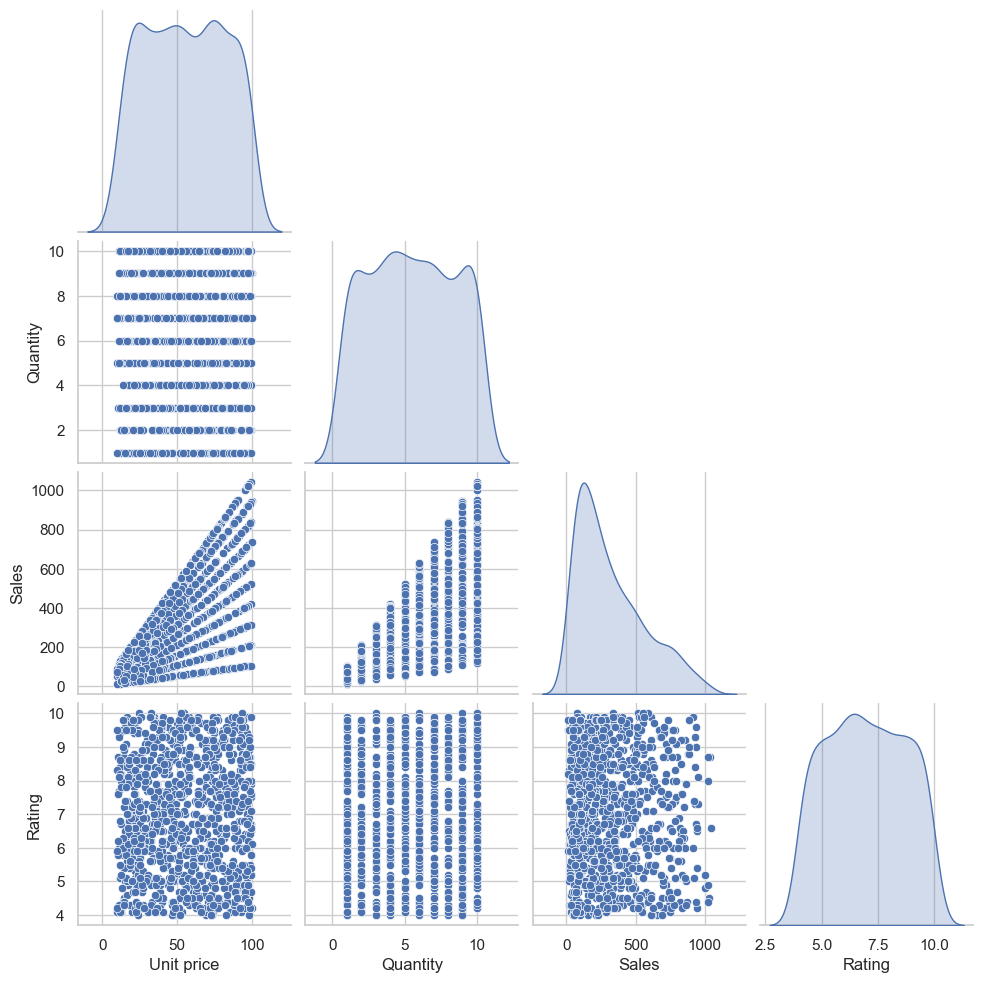

In [47]:
sns.pairplot(
    sales[["Unit price","Quantity","Sales","Rating"]],
    diag_kind="kde",
    corner=True
)

plt.show()

## Regression Plot

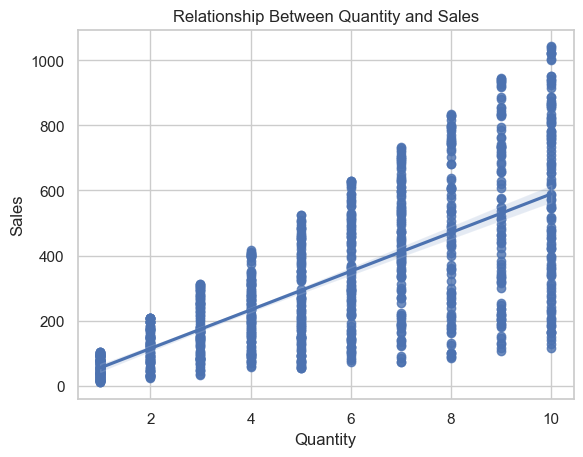

In [20]:
sns.regplot(x="Quantity", y="Sales", data=sales)

plt.title("Relationship Between Quantity and Sales")

plt.show()

# Statistical Inference

### Confidence Interval for Mean Sales

To estimate the true average sales value of the supermarket transactions, we calculate a **95% confidence interval for the mean Sales**.

A confidence interval provides a range of values that is likely to contain the true population mean.

The confidence level of **95%** means that if we repeated the sampling process many times, about **95% of the calculated confidence intervals would contain the true population mean**.

In [21]:
sales_mean = sales["Sales"].mean()
sales_std = sales["Sales"].std()
n = len(sales)

confidence = 0.95

ci = stats.t.interval(
    confidence,
    df=n-1,
    loc=sales_mean,
    scale=sales_std/np.sqrt(n)
)

ci

(np.float64(307.7084118264187), np.float64(338.2250861735813))

The calculated 95% confidence interval provides an estimated range
for the true average transaction value.

This means that if we repeatedly sampled similar datasets,
approximately 95% of the calculated intervals would contain
the true population mean sales value.

## Hypothesis Testing: Customer Type

We test whether the average sales value differs
between Member and Normal customers.

H0: There is no difference in mean sales between the groups.

Ha: Mean sales differ between Member and Normal customers.

In [22]:
members = sales[sales["Customer type"] == "Member"]["Sales"]
normal = sales[sales["Customer type"] == "Normal"]["Sales"]

t_stat, p_value = stats.ttest_ind(members, normal)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.8749713466198594
p-value: 0.06108851551521512


The t-test resulted in a p-value of 0.061.

Because the p-value is greater than the chosen significance
level of 0.05, we fail to reject the null hypothesis.

This suggests that there is no statistically significant
difference in average sales between Member and Normal customers
in this dataset.

Although the difference is not statistically significant
at the 5% level, the p-value is relatively close to the threshold,
which may suggest a weak tendency toward different spending behavior.
However, further data would be required to confirm such a pattern.

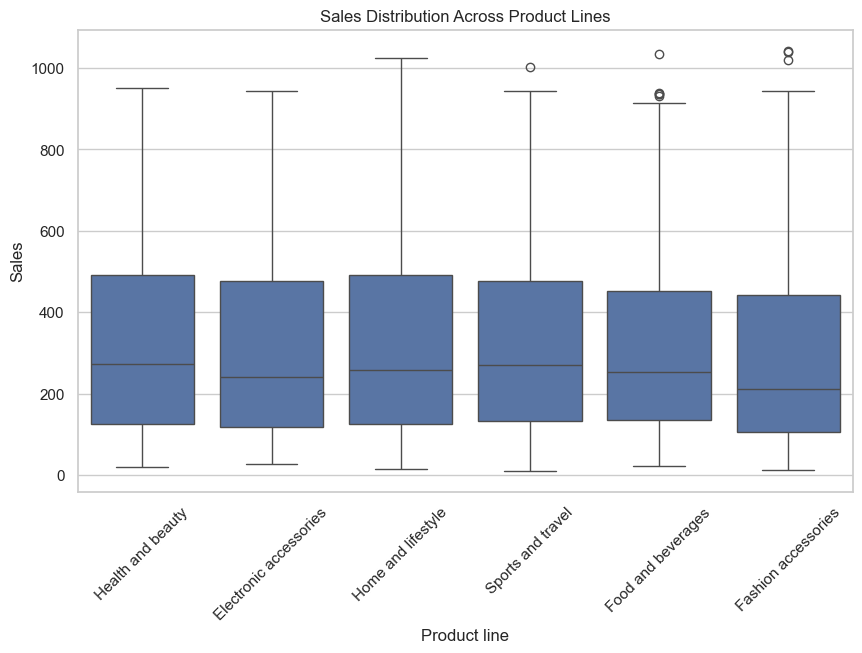

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Product line", y="Sales", data=sales)

plt.xticks(rotation=45)
plt.title("Sales Distribution Across Product Lines")

plt.show()

The boxplot illustrates the distribution of sales across
different product categories and helps visualize potential
differences in average transaction values.

## ANOVA Test: Sales Across Product Lines

To determine whether average sales differ across product categories,
we perform a one-way ANOVA test.

H0: The mean sales are equal across all product lines.

Ha: At least one product line has a different mean sales value.

In [24]:
health_beauty = sales[sales["Product line"] == "Health and beauty"]["Sales"]
electronics = sales[sales["Product line"] == "Electronic accessories"]["Sales"]
home_lifestyle = sales[sales["Product line"] == "Home and lifestyle"]["Sales"]
sports = sales[sales["Product line"] == "Sports and travel"]["Sales"]
food = sales[sales["Product line"] == "Food and beverages"]["Sales"]
fashion = sales[sales["Product line"] == "Fashion accessories"]["Sales"]

f_stat, p_value = stats.f_oneway(
    health_beauty,
    electronics,
    home_lifestyle,
    sports,
    food,
    fashion
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.3379647544618803
p-value: 0.8900398045913398


The ANOVA test resulted in a p-value greater than 0.05.

Therefore, we fail to reject the null hypothesis and conclude
that there is no statistically significant evidence that
average sales differ across product lines.

## Regression Analysis

To further understand the factors influencing sales, we build a multiple linear regression model. The goal of this model is to predict **Sales** based on several explanatory variables from the dataset.

Regression analysis helps identify which variables have the strongest impact on sales and allows us to quantify these relationships.

In this section we will:
- Prepare the dataset for modeling
- Encode categorical variables
- Train a multiple linear regression model
- Evaluate model performance

In [25]:
# Select relevant features for regression
model_data = sales[['Sales','Unit price','Quantity','Rating','Branch','Customer type','Gender','Payment','Product line']]

model_data.head()

,Sales,Unit price,Quantity,Rating,Branch,Customer type,Gender,Payment,Product line
0,548.9715,74.69,7,9.1,Alex,Member,Female,Ewallet,Health and beauty
1,80.2200,15.28,5,9.6,Giza,Normal,Female,Cash,Electronic accessories
2,340.5255,46.33,7,7.4,Alex,Normal,Female,Credit card,Home and lifestyle
3,489.0480,58.22,8,8.4,Alex,Member,Female,Ewallet,Health and beauty
4,634.3785,86.31,7,5.3,Alex,Member,Female,Ewallet,Sports and travel


In [26]:
# Convert categorical variables to dummy variables
model_data = pd.get_dummies(model_data, drop_first=True).astype(int)

model_data.head()

,Sales,Unit price,Quantity,Rating,Branch_Cairo,Branch_Giza,Customer type_Normal,Gender_Male,Payment_Credit card,Payment_Ewallet,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel
0,548,74,7,9,0,0,0,0,0,1,0,0,1,0,0
1,80,15,5,9,0,1,1,0,0,0,0,0,0,0,0
2,340,46,7,7,0,0,1,0,1,0,0,0,0,1,0
3,489,58,8,8,0,0,0,0,0,1,0,0,1,0,0
4,634,86,7,5,0,0,0,0,0,1,0,0,0,0,1


In [27]:
# Define target variable
y = model_data['Sales'].astype(int)

# Define predictors
X = model_data.drop('Sales', axis=1)

X.head()

,Unit price,Quantity,Rating,Branch_Cairo,Branch_Giza,Customer type_Normal,Gender_Male,Payment_Credit card,Payment_Ewallet,Product line_Fashion accessories,Product line_Food and beverages,Product line_Health and beauty,Product line_Home and lifestyle,Product line_Sports and travel
0,74,7,9,0,0,0,0,0,1,0,0,1,0,0
1,15,5,9,0,1,1,0,0,0,0,0,0,0,0
2,46,7,7,0,0,1,0,1,0,0,0,0,1,0
3,58,8,8,0,0,0,0,0,1,0,0,1,0,0
4,86,7,5,0,0,0,0,0,1,0,0,0,0,1


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
import statsmodels.api as sm

# Add constant
X_train_sm = sm.add_constant(X_train)

# Train model
model = sm.OLS(y_train, X_train_sm).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.888
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     443.0
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        15:33:36   Log-Likelihood:                -4655.9
No. Observations:                 800   AIC:                             9342.
Df Residuals:                     785   BIC:                             9412.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

### Interpretation of the Regression Model

The regression model was built to understand which factors influence **Sales** in the supermarket dataset.

#### Model Fit

The model shows a very strong fit to the data.

- **R-squared = 0.888**  
  This means that approximately **88.8% of the variability in Sales is explained by the predictors included in the model**.

- **Adjusted R-squared = 0.886**  
  The adjusted value is very close to R², which indicates that the predictors used in the model contribute meaningfully and the model is not overfitted.

The **F-statistic = 443.0** with **p-value = 0.00**, which means that the regression model as a whole is statistically significant. In other words, the predictors collectively explain variation in Sales.

#### Significant Predictors

Looking at the **p-values (P>|t|)**, variables with p-values below **0.05** are considered statistically significant.

The most significant predictors in the model are:

- **Unit price**
- **Quantity**

Both variables have very large t-values and p-values close to zero, indicating a strong statistical relationship with Sales.

This is expected because Sales are directly related to the price of the product and the number of units purchased.

#### Non-Significant Variables

Several variables have **p-values greater than 0.05**, meaning their effect on Sales is not statistically significant in this model. These include:

- Rating
- Branch
- Customer type
- Gender
- Payment method
- Product line

This suggests that these variables do not strongly influence the total sales value when price and quantity are already included in the model.

#### Interpretation

Overall, the regression results indicate that **Sales are primarily driven by Unit price and Quantity**, while customer characteristics and payment methods have relatively little impact on the total transaction value.

### Model Validation

To evaluate how well the regression model generalizes to unseen data, we test the model on the **test dataset** that was created during the train-test split.

Predictions are generated for the test set and model performance is evaluated using:

- **MAE (Mean Absolute Error)** – average absolute difference between predicted and actual values
- **RMSE (Root Mean Squared Error)** – square root of the average squared prediction error

Lower values of these metrics indicate better predictive performance.

In [30]:
# Add constant to test set
X_test_sm = sm.add_constant(X_test)

# Generate predictions
y_pred = model.predict(X_test_sm)

y_pred[:5]

521    519.473476
737    589.694801
740    409.690214
660     88.146753
411    -94.338050
dtype: float64

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 59.48319402730761
RMSE: 79.87797565766088


### Model Validation Results

To evaluate the predictive performance of the regression model, predictions were generated for the **test dataset**, which was not used during model training. The model performance was assessed using two common regression metrics: **MAE (Mean Absolute Error)** and **RMSE (Root Mean Squared Error)**.

The obtained results are:

- **MAE = 59.48**
- **RMSE = 79.88**

The **Mean Absolute Error (MAE)** indicates that, on average, the predicted sales values differ from the actual sales values by approximately **59 monetary units**.

The **Root Mean Squared Error (RMSE)** is slightly higher because it penalizes larger prediction errors more strongly. An RMSE of about **79.88** suggests that some transactions have larger deviations between predicted and actual sales.

Considering that sales values in the dataset vary widely, these error levels are reasonable and indicate that the model is able to capture the main drivers of sales. The results confirm that the regression model provides a **useful approximation of sales values**, although prediction errors still exist for some observations.

Overall, the validation results show that the model has **good explanatory power and acceptable predictive performance**.

### Additional Model Diagnostics

To further evaluate the regression model, we examine the relationship between predicted and actual sales values.  
If the model performs well, predicted values should closely follow the actual observed values.

We also examine the distribution of residuals to understand whether prediction errors appear random or show systematic patterns.

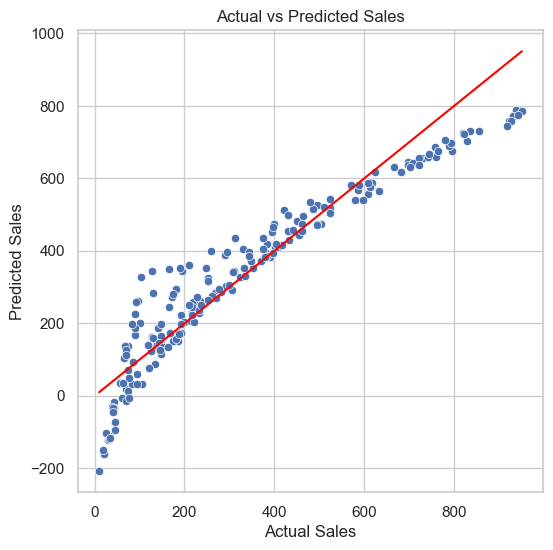

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

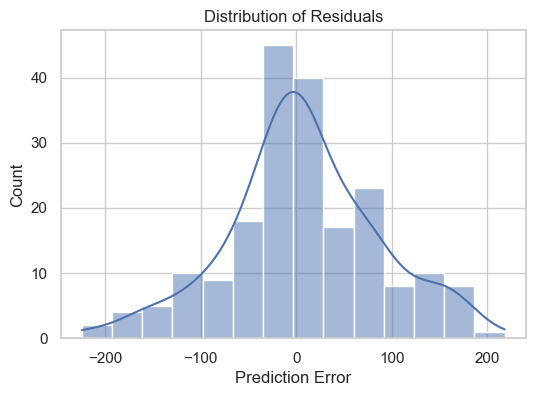

In [38]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")
plt.xlabel("Prediction Error")

plt.show()

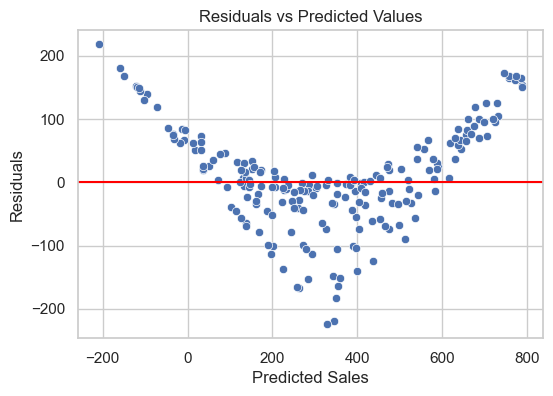

In [39]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

### Diagnostic Analysis of the Regression Model

To better understand the performance of the regression model, several diagnostic visualizations were examined: the relationship between actual and predicted values, the distribution of residuals, and the residuals plotted against predicted values.

#### Actual vs Predicted Sales

The scatter plot comparing **actual sales and predicted sales** shows that most observations lie close to the diagonal reference line. This indicates that the model predictions generally follow the true sales values.  

Although some deviations are visible for very small and very large sales values, the overall pattern suggests that the model captures the main relationship between predictors and the target variable.

#### Distribution of Residuals

The histogram of residuals shows that prediction errors are approximately **symmetrically distributed around zero**. This indicates that the model does not systematically overpredict or underpredict sales.  

Most residuals are concentrated around zero, while larger errors appear less frequently. This pattern suggests that the model errors are reasonably well-behaved.

#### Residuals vs Predicted Values

The residual plot shows how prediction errors behave across different predicted sales values. Ideally, residuals should appear randomly scattered around zero.

In this case, the residuals form a slight curved pattern, suggesting that the relationship between predictors and sales might not be perfectly linear. However, the residuals still remain centered around zero, indicating that the model provides a generally reasonable approximation of the data.

#### Overall Assessment

Taken together, the diagnostic plots confirm that the regression model has **strong explanatory power and acceptable predictive performance**. The model captures the main drivers of sales, while prediction errors remain relatively moderate for most observations.

### Multicollinearity Check (VIF)

Before interpreting regression coefficients, it is useful to examine whether the predictor variables are strongly correlated with each other.  

High correlation between predictors is known as **multicollinearity**, which can distort regression coefficients and make the model less stable.

To evaluate this issue, we calculate the **Variance Inflation Factor (VIF)** for each predictor variable.

VIF measures how much the variance of a regression coefficient increases due to multicollinearity.

Common interpretation guidelines:

- **VIF ≈ 1** → no multicollinearity  
- **VIF between 1–5** → moderate correlation but usually acceptable  
- **VIF > 5 (or 10)** → potentially problematic multicollinearity

In [41]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# add constant
X_vif = sm.add_constant(X)

# compute VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) 
                   for i in range(X_vif.shape[1])]

vif_data

,Variable,VIF
0,const,34.410814
1,Unit price,1.006706
2,Quantity,1.017866
3,Rating,1.009823
4,Branch_Cairo,1.330648
5,Branch_Giza,1.339578
6,Customer type_Normal,1.029655
7,Gender_Male,1.039906
8,Payment_Credit card,1.324281
9,Payment_Ewallet,1.326450


### Multicollinearity Interpretation

The Variance Inflation Factor (VIF) was calculated to evaluate potential multicollinearity among the predictor variables.

The results show that all predictors have **VIF values close to 1**, with the highest values slightly above **1.7**. These values are well below the commonly used thresholds of **5 or 10**, which are typically considered indicators of problematic multicollinearity.

This suggests that the predictor variables are not strongly correlated with each other and that multicollinearity is not a concern in this model.

Therefore, the regression coefficients can be interpreted with confidence, as the estimated relationships between the predictors and the target variable (Sales) are not distorted by strong correlations between explanatory variables.

## Time Series Analysis of Sales

In addition to cross-sectional analysis, it is useful to examine how sales evolve over time.  
Time series analysis helps identify **trends, fluctuations, and potential seasonal patterns** in sales.

In this section, sales values will be aggregated by date to observe how total sales change over time. This allows us to identify whether sales remain stable or show increasing or decreasing trends.

In [48]:
# convert Date column to datetime
sales['Date'] = pd.to_datetime(sales['Date'])

# aggregate sales by date
daily_sales = sales.groupby('Date')['Sales'].sum().reset_index()

daily_sales.head()

,Date,Sales
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


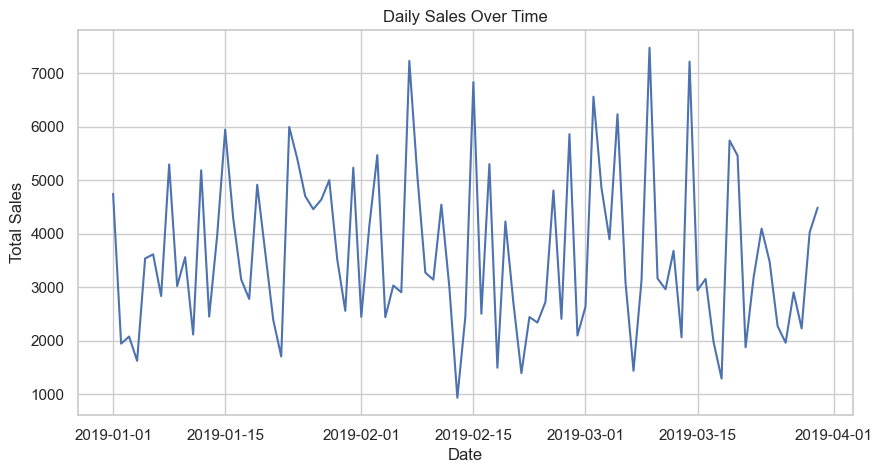

In [49]:
plt.figure(figsize=(10,5))

sns.lineplot(data=daily_sales, x='Date', y='Sales')

plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

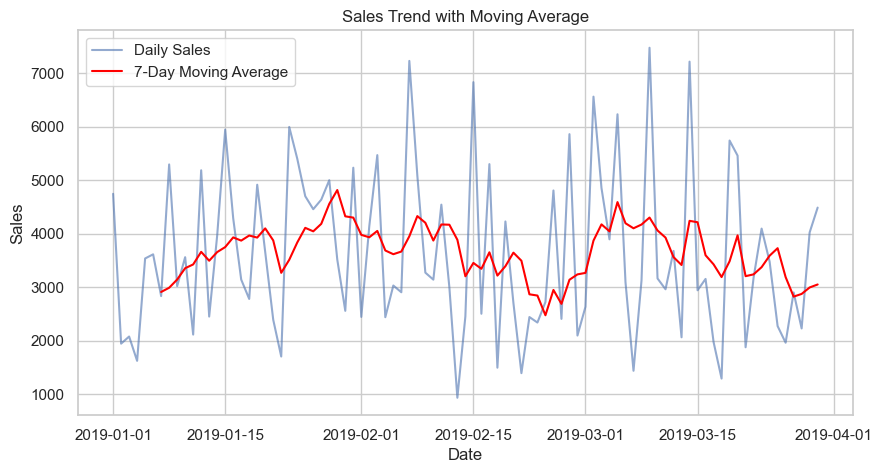

In [50]:
daily_sales['rolling_mean'] = daily_sales['Sales'].rolling(window=7).mean()

plt.figure(figsize=(10,5))

plt.plot(daily_sales['Date'], daily_sales['Sales'], label="Daily Sales", alpha=0.6)
plt.plot(daily_sales['Date'], daily_sales['rolling_mean'], label="7-Day Moving Average", color='red')

plt.title("Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

### Interpretation of Sales Time Series

The time series visualization shows how total daily sales evolve over time. The first plot illustrates the raw daily sales values, which fluctuate considerably from day to day. This variability reflects natural differences in daily customer activity and purchasing behavior.

Several peaks in the graph indicate days with particularly high sales, while some days show noticeably lower sales volumes. These fluctuations are typical in retail datasets where customer traffic varies across days.

To better observe the underlying trend, a **7-day moving average** was calculated. The moving average smooths short-term fluctuations and highlights the general direction of sales over time.

From the moving average plot, we can observe that:

- Sales generally fluctuate around a relatively stable level.
- There are short periods where sales increase slightly, followed by small decreases.
- No strong long-term upward or downward trend is visible during the observed time period.

This suggests that sales remain relatively stable over time, with variations primarily driven by short-term daily changes rather than long-term structural trends.

Overall, the time series analysis indicates that supermarket sales show **moderate daily volatility but no clear long-term trend or seasonality within the observed period**.

### Simple Sales Forecast

To illustrate a basic forecasting approach, we use a simple linear regression model to estimate the trend in daily sales.

The model treats time as an explanatory variable and attempts to capture the general direction of sales over time. Although this approach is relatively simple, it provides a basic example of how future sales values might be estimated.

The forecast line represents the predicted trend based on historical sales data.

In [51]:
# create time index
daily_sales['time_index'] = range(len(daily_sales))

daily_sales.head()

,Date,Sales,rolling_mean,time_index
0,2019-01-01,4745.1810,NaN,0
1,2019-01-02,1945.5030,NaN,1
2,2019-01-03,2078.1285,NaN,2
3,2019-01-04,1623.6885,NaN,3
4,2019-01-05,3536.6835,NaN,4


In [52]:
from sklearn.linear_model import LinearRegression

X_time = daily_sales[['time_index']]
y_time = daily_sales['Sales']

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

daily_sales['trend_prediction'] = trend_model.predict(X_time)

daily_sales.head()

,Date,Sales,rolling_mean,time_index,trend_prediction
0,2019-01-01,4745.1810,NaN,0,3733.722064
1,2019-01-02,1945.5030,NaN,1,3731.338378
2,2019-01-03,2078.1285,NaN,2,3728.954692
3,2019-01-04,1623.6885,NaN,3,3726.571006
4,2019-01-05,3536.6835,NaN,4,3724.187320


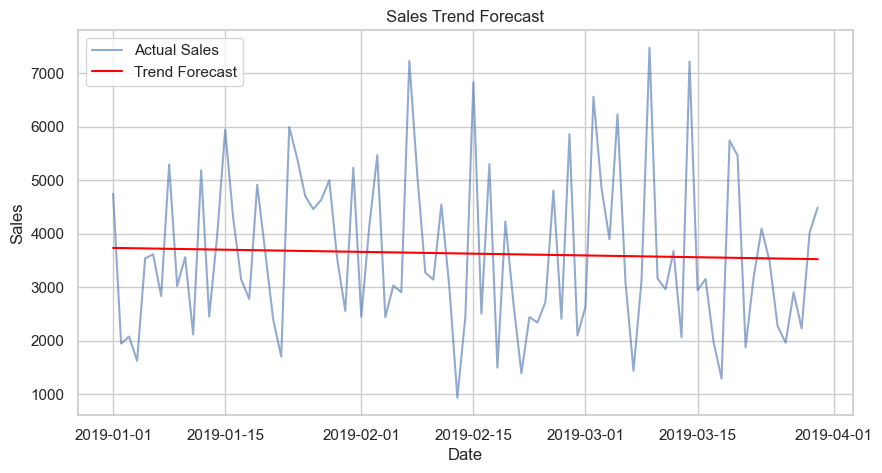

In [53]:
plt.figure(figsize=(10,5))

plt.plot(daily_sales['Date'], daily_sales['Sales'], label="Actual Sales", alpha=0.6)
plt.plot(daily_sales['Date'], daily_sales['trend_prediction'], label="Trend Forecast", color='red')

plt.title("Sales Trend Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

### Interpretation of Sales Forecast

To illustrate a simple forecasting approach, a linear regression model was applied to the time series of daily sales. In this model, time was treated as an explanatory variable to capture the general trend of sales over the observed period.

The red line in the plot represents the predicted trend based on historical data, while the blue line shows the actual daily sales values.

From the visualization we can observe that:

- Daily sales fluctuate significantly from day to day.
- The predicted trend line is relatively flat with a slight downward tendency.
- This suggests that overall sales levels remain relatively stable during the observed time period.

The forecast model does not attempt to predict individual daily fluctuations but instead captures the **general direction of sales over time**.

Since the dataset covers only a limited time window, the model mainly indicates that sales are relatively stable and do not show a strong long-term upward or downward trend.

This simple forecasting example demonstrates how historical sales data can be used to estimate future trends and support business planning decisions.

## Business Insights

The analysis of supermarket sales data provides several insights that may be useful for business decision-making.

First, the regression analysis showed that **Unit price and Quantity are the strongest drivers of total sales**. This is expected, since higher product prices and larger purchase quantities directly increase the total transaction value. For business strategy, this suggests that promoting products with higher unit prices or encouraging customers to purchase multiple items could increase revenue.

Second, customer-related variables such as **Gender, Customer type, and Payment method** were not statistically significant predictors of sales in the regression model. This indicates that the value of individual purchases is not strongly determined by these customer characteristics. Instead, purchasing behavior appears to be driven mainly by the products being purchased.

Third, the exploratory analysis showed that **sales vary considerably from day to day**, but the time series analysis indicates that overall sales levels remain relatively stable over time. This suggests that the supermarket experiences regular daily fluctuations in demand rather than strong long-term growth or decline.

Additionally, the diagnostic analysis confirmed that the regression model performs reasonably well and that the main statistical assumptions are largely satisfied. Multicollinearity between predictors was also very low, which increases confidence in the stability of the model results.

These insights may help businesses better understand which factors influence sales and where managerial attention should be focused.

## Conclusion

This project applied several statistical and data analysis techniques to explore supermarket sales data and identify key patterns in customer purchasing behavior.

The analysis began with exploratory data analysis, which provided an overview of the dataset and revealed general patterns in sales distribution and customer activity. Confidence intervals and hypothesis testing were then used to evaluate statistical relationships within the data.

A multiple linear regression model was developed to explain sales using several predictors. The model achieved a high explanatory power (R² ≈ 0.89), indicating that most of the variation in sales can be explained by the variables included in the model. Model validation and diagnostic checks confirmed that the model performs reasonably well and that its assumptions are largely satisfied.

Finally, time series analysis was used to examine how sales change over time. The results showed noticeable daily fluctuations but no strong long-term trend, suggesting relatively stable sales patterns.

Overall, the analysis demonstrates how statistical methods and machine learning techniques can be used to better understand retail sales data and support data-driven decision making in business environments.